[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/main/ch04_workbook.ipynb)

# `cat`, `mat` and `dog`

A computer measures how close two words are by the cosine of their vectors,
and each vector holds whatever was counted for its word. Is `mat` or `dog`
closer to `cat`, and what would a computer count to decide?

In [1]:
#@title Setup: run this cell first
import os
import re
import urllib.request
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

MIRROR_REF = "main"
TEXT_URL = f"https://raw.githubusercontent.com/josterri/predicting-the-next-words-notebooks/{MIRROR_REF}/data/pride_and_prejudice.txt"


def load_novel():
    """Pride and Prejudice as lowercase word tokens, one list per chapter."""
    if os.environ.get("PNW_TEXT"):
        text = open(os.environ["PNW_TEXT"], encoding="utf-8").read()
    else:
        try:
            text = urllib.request.urlopen(TEXT_URL).read().decode("utf-8")
        except OSError as e:
            raise RuntimeError(f"The text did not download from {TEXT_URL}: {e}. "
                               "Run this cell again; every cell below needs it.") from None
    chapters = re.split(r"(?m)^CHAPTER [IVXLC]+\.$", text)[1:]
    return [re.findall(r"[a-z]+(?:'[a-z]+)*", c.lower().replace("’", "'")) for c in chapters]


# The lecture's three sentences; a word's company is the words within one position of it.
SENTENCES = ["the cat sat on the mat", "the dog sat on the rug", "the cat chased the dog"]
TYPES = list(dict.fromkeys(" ".join(SENTENCES).split()))  # the eight words, in order of first use
# The lecture's stylised centre vector of cat and context vector of sat, four numbers each.
V_CAT, U_SAT = np.array([0.6, 0.4, -0.2, 0.2]), np.array([1.0, 0.8, -0.5, 0.4])
# A word of the novel needs 5 uses for a row and a dense vector of 100 numbers; 5 is also fastText's
# default minCount, below which a word gets no vector of its own. FastText's character n-grams run
# from 3 to 6 characters: Bojanowski et al. 2017, section 3.2.
MIN_COUNT, DIM, LENGTHS = 5, 100, (3, 6)
plt.rcParams.update({"xtick.labelsize": 8, "ytick.labelsize": 8})


# A setting a cell refuses: Colab prints the one sentence, without the stack.
class Refused(Exception):
    _render_traceback_ = lambda self: [str(self)]  # noqa: E731


# The refusal names the setting, its value cut to 40 characters, its type and what it takes.
#% Python 3.13 refuses to print an int of more than 4,300 digits, so a long int is named by its bits.
def need(ok, name, value, rule):
    long = isinstance(value, int) and value.bit_length() > 128
    shown = f"an int of {value.bit_length():,} bits" if long else repr(value)[:40]
    if not ok:
        raise Refused(f"{name} is {shown}, of type {type(value).__name__}: {name} takes {rule}.")


def word_of(name, value):  # the setting as one lowercase word
    need(isinstance(value, str) and value.strip().isalpha() and len(value.strip()) <= 30, name, value, "a word of 1 to 30 letters")
    return value.strip().lower()


# The cosine of two count vectors held as Counters: their dot product over their two lengths,
# rounded to 12 decimals so that two equal cosines reached by different sums compare equal.
def cos(a, b):
    dot = sum(a[k] * b[k] for k in a)
    return round(float(dot / np.sqrt(sum(x * x for x in a.values()) * sum(x * x for x in b.values()))), 12)


def sigma(z):  # the sigmoid 1 / (1 + e^(−z)); no accepted setting gives a score that overflows it
    return 1 / (1 + np.exp(-z))


# Side by side, one chart of labelled horizontal bars per (title, labels, values, x label, unit,
# decimals); an exact 0 is labelled 0. A unit chart holds cosines or probabilities: its ticks stop at 1,
# and its axis runs to 1.3 to hold the labels. Any other axis gets a margin of 0.4 of the span beyond
# the longest bar on each side that has one, so a label never reaches the word beside its bar.
def panels(*charts):
    fig, axes = plt.subplots(1, len(charts), figsize=(6, 3.5), layout="constrained")
    for ax, (title, labels, values, xlabel, unit, d) in zip(axes, charts):
        bars = ax.barh(range(len(values)), values, tick_label=labels)
        ax.bar_label(bars, labels=["0" if x == 0 else f"{x:.{d}f}" for x in values], padding=2, fontsize=8)
        lo, hi = min(0, *values), max(0, *values)
        xlim = (0, 1.3) if unit else (lo - 0.4 * (hi - lo) - 0.1 if lo < 0 else 0, hi + 0.4 * (hi - lo) + 0.1)
        ax.set(title=title, xlabel=xlabel, xlim=xlim, ylim=(len(values) - 0.5, -0.5))
        ax.xaxis.set_major_locator(plt.FixedLocator([0, 0.25, 0.5, 0.75, 1]) if unit else plt.AutoLocator())
    plt.show()


# Step 1: the word against each other word of the three sentences, by one-hot vectors (a 1 on the
# word's own axis, 0 on every other) and by letter counts.
def spelling(word):
    word = word_of("WORD", word)
    others = [w for w in TYPES if w != word]
    hot = [cos(Counter({word: 1}), Counter({w: 1})) for w in others]
    return word, others, hot, [cos(Counter(word), Counter(w)) for w in others]


# Step 2: each word's row counts its neighbours within one position, over the three sentences and a
# fourth sentence: an empty one, or 2 to 10 words of letters with no digit, each of 15 letters or fewer.
def company(fourth=""):
    extra = re.findall(r"[^\W\d_]+(?:['’][^\W\d_]+)*", fourth.lower()) if isinstance(fourth, str) else []
    ok = isinstance(fourth, str) and not re.search(r"\d", fourth) and (not fourth.strip() or (2 <= len(extra) <= 10 and max(map(len, extra)) <= 15))
    need(ok, "FOURTH_SENTENCE", fourth, 'the empty sentence "", or 2 to 10 words of 15 letters or fewer, no digit')
    rows = {}
    for t in [s.split() for s in SENTENCES] + [extra]:
        for i, w in enumerate(t):
            rows.setdefault(w, Counter()).update(t[max(i - 1, 0):i] + t[i + 1:i + 2])
    return rows


# PMI(w, c) = ln(M_wc · N / (M_w · M_c)) for each neighbour c of w; N is the sum of all counts.
def pmi(rows, w="cat"):
    total = {x: sum(r.values()) for x, r in rows.items()}
    return {c: round(float(np.log(m * sum(total.values()) / (total[w] * total[c]))), 12) for c, m in rows[w].items()}


def show_company(fourth):
    rows, p = company(fourth), pmi(company(fourth))
    for w in ("cat", "dog", "mat"):
        print(f"row of {w}: " + ", ".join(f"{c} {m}" for c, m in rows[w].items()))
    others = sorted((w for w in rows if w != "cat"), key=lambda w: -cos(rows["cat"], rows[w]))
    panels(("", others, [cos(rows["cat"], rows[w]) for w in others], "cosine with cat's row", True, 3),
           ("", [f"{c}, count {m}" for c, m in rows["cat"].items()], list(p.values()), "PMI with cat, natural log", False, 2))


# Step 3: one step for the real pair moves v_cat by η (1 − σ(s)) u_sat, with u_sat held fixed.
def nudge(eta):
    need(type(eta) in (int, float) and 0 <= eta <= 10, "ETA", eta, "a number from 0 to 10")
    step = eta * (1 - sigma(V_CAT @ U_SAT)) * U_SAT
    return V_CAT @ U_SAT, (V_CAT + step) @ U_SAT


def ngrams(word):  # FastText's character n-grams of the word with its markers < and >
    w = "<" + word_of("FASTTEXT_WORD", word) + ">"
    return [w[i:i + n] for n in range(LENGTHS[0], LENGTHS[1] + 1) for i in range(len(w) - n + 1)]


def neighbours(word, k=3):  # the k words whose dense vectors have the largest cosine with the word's
    c = dense @ dense[index[word]] / np.maximum(np.linalg.norm(dense, axis=1) * np.linalg.norm(dense[index[word]]), 1e-12)
    return [(vocab[j], c[j]) for j in np.argsort(-c, kind="stable") if j != index[word]][:k]


tokens = [w for chapter in load_novel() for w in chapter]
vocab = [w for w, c in Counter(tokens).most_common() if c >= MIN_COUNT]
index, n = {w: i for i, w in enumerate(vocab)}, len(vocab)
ids = np.array([index.get(w, -1) for w in tokens])
both = (ids[:-1] >= 0) & (ids[1:] >= 0)  # neighbouring tokens, one position apart, both with a row
M = np.bincount(ids[:-1][both] * n + ids[1:][both], minlength=n * n).reshape(n, n)
M = M + M.T  # each pair counted from both sides, as in the three sentences
# M_i · M_j / N, the count chance gives a pair; PMI is the log of the count over it, kept from 0 up.
ppmi = np.maximum(np.log(np.where(M > 0, M * M.sum() / np.maximum(np.outer(M.sum(1), M.sum(1)), 1), 1)), 0)
U, S, _ = np.linalg.svd(ppmi, hermitian=True)
dense = U[:, :DIM] * S[:DIM]  # each word's row of U_k Σ_k
display(Markdown(f"The three sentences: {len(' '.join(SENTENCES).split())} tokens of {len(TYPES)} word types. The novel: {len(tokens):,} tokens."))

The three sentences: 17 tokens of 8 word types. The novel: 122,174 tokens.

## 1. One-hot indices

One-hot encoding gives each of the eight words of the three sentences its own
axis; a vector of letter counts gives each letter an axis. Run the cell to
compare `cat` with the other seven words both ways: which word is closest to
`cat` by one-hot vectors, and which by spelling? Then put a word
of your own into `WORD`, such as `act` or `puppy`, and run it again.

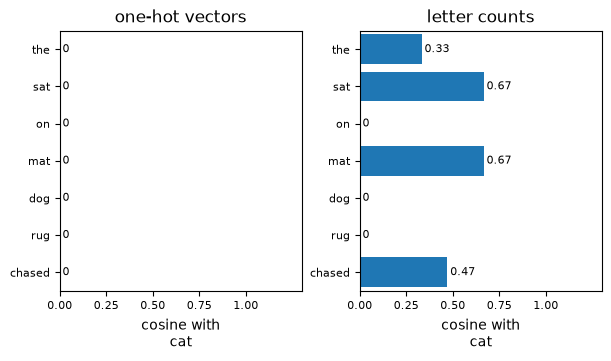

In [2]:
WORD = "cat"
word, others, hot, spell = spelling(WORD)
panels(("one-hot vectors", others, hot, f"cosine with\n{word}", True, 2),
       ("letter counts", others, spell, f"cosine with\n{word}", True, 2))

### Solution

In [3]:
word, others, hot, spell = spelling(WORD)
best = [f"`{w}`" for w, c in zip(others, spell) if c == max(spell)]
near = f"put {' and '.join(best)} closest at {max(spell):.2f}{', in a tie' if len(best) > 1 else ''}"
near = near if max(spell) else f"give every other word cosine 0, since none shares a letter with `{word}`"
frame = f"; `dog` stands at {cos(Counter(word), Counter('dog')):g}, as the frame 'Letter Counts Put `mat` Beside `cat` and Leave `dog` at Zero' prints"
display(Markdown(f"One-hot vectors give all {len(others)} other words cosine {max(hot):g} with `{word}`, as the frame 'Every Pair of "
                 f"Distinct One-Hot Vectors Has a Cosine of Zero' prints. Letter counts {near}{frame if word == 'cat' else ''}."))

One-hot vectors give all 7 other words cosine 0 with `cat`, as the frame 'Every Pair of Distinct One-Hot Vectors Has a Cosine of Zero' prints. Letter counts put `sat` and `mat` closest at 0.67, in a tie; `dog` stands at 0, as the frame 'Letter Counts Put `mat` Beside `cat` and Leave `dog` at Zero' prints.

## 2. A word's company

A co-occurrence row counts the words within one position of each use of a
word, and PMI scores a pair by how far its count exceeds what chance gives it.
Run the cell to compare the row of `cat` with every other row by cosine, and
to score each neighbour of `cat` by PMI: is `dog` or `mat` closer to `cat` by
company, and which neighbour does PMI put first? Then put chapter 3's fourth
sentence, `the dog chased the cat`, into `FOURTH_SENTENCE` and run it again.

row of cat: the 2, sat 1, chased 1
row of dog: the 2, sat 1
row of mat: the 1


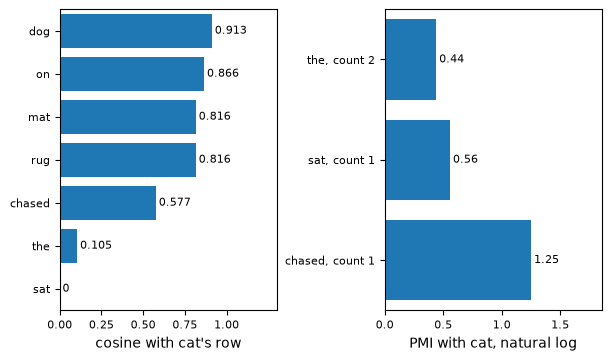

In [4]:
FOURTH_SENTENCE = ""
show_company(FOURTH_SENTENCE)

### Solution

In [5]:
rows, p = company(FOURTH_SENTENCE), pmi(company(FOURTH_SENTENCE))
cd, cm = cos(rows["cat"], rows["dog"]), cos(rows["cat"], rows["mat"])
closer = "`dog` is closer" if cd > cm else "`mat` is closer" if cm > cd else "`dog` and `mat` stand equally close"
ranked = ", ".join(f"`{c}` {p[c]:.2f}" for c in sorted(p, key=lambda c: -p[c]))  # a tie keeps the order of first use
tie = " (equal values in their order of first use)" if len(set(p.values())) < len(p) else ""
frames = ", as the frames 'The Rows of `cat`, `dog` and `mat`, Compared by Cosine' and 'PMI Scores a Pair by How Far It Exceeds Chance' print"
display(Markdown(f"By company, {closer} to `cat`, {cd:.3f} for `dog` against {cm:.3f} for `mat`, and PMI ranks the neighbours "
                 f"of `cat` as {ranked}{tie}{frames if rows == company() else ''}."))

By company, `dog` is closer to `cat`, 0.913 for `dog` against 0.816 for `mat`, and PMI ranks the neighbours of `cat` as `chased` 1.25, `sat` 0.56, `the` 0.44, as the frames 'The Rows of `cat`, `dog` and `mat`, Compared by Cosine' and 'PMI Scores a Pair by How Far It Exceeds Chance' print.

## 3. Prediction by negative sampling

Skip-gram gives every word a centre vector v and a context vector u, scores a
pair by the dot product of the two, and reads the sigmoid σ of the score as
the chance that the pair is real. One step for the real pair `cat`, `sat`
moves v_cat toward u_sat by the learning rate `ETA` times the error, the gap
between the target 1 and σ, with u_sat held fixed. Run the cell, then set
`ETA` to 1 and to 2: how far does one step raise the score of `cat` and `sat`
at each learning rate?

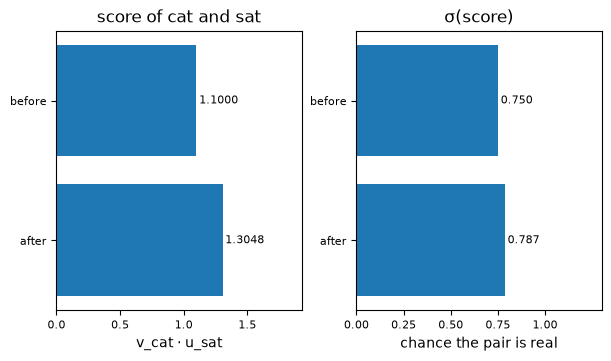

In [6]:
ETA = 0.4
s, s2 = nudge(ETA)
panels(("score of cat and sat", ["before", "after"], [s, s2], "v_cat · u_sat", False, 4),
       ("σ(score)", ["before", "after"], [sigma(s), sigma(s2)], "chance the pair is real", True, 3))

### Solution

In [7]:
s, s2 = nudge(ETA)
err, uu = 1 - sigma(s), U_SAT @ U_SAT
frame = ", as the frame 'One Step Raises the Score of `cat` and `sat`' computes it" if ETA == 0.4 else ""
display(Markdown(f"At learning rate {ETA:g} one step raises the score of `cat` and `sat` by {s2 - s:.4f}, from {s:.4f} to {s2:.4f}: the rise "
                 f"is η × error × (u_sat · u_sat) = {ETA:g} × {err:.4f} × {uu:.2f}, with the error 1 − σ({s:.4f}). With the error rounded "
                 f"to two digits, {round(err, 2):.2f}{frame}, the score reaches {s + ETA * round(err, 2) * uu:.4f}."))

At learning rate 0.4 one step raises the score of `cat` and `sat` by 0.2048, from 1.1000 to 1.3048: the rise is η × error × (u_sat · u_sat) = 0.4 × 0.2497 × 2.05, with the error 1 − σ(1.1000). With the error rounded to two digits, 0.25, as the frame 'One Step Raises the Score of `cat` and `sat`' computes it, the score reaches 1.3050.

## Appendix. GloVe, FastText and one vector per word

Over the whole novel, each word used 5 times or more, fastText's default
minimum count, gets a row that counts its neighbours within one position
among those words, as over the three sentences, and positive PMI weights each
cell of the count matrix M:

PPMI(i, j) = max(0, ln(M_ij · N / (M_i · M_j))),

with M_ij the pair's count, M_i and M_j the two row sums and N the total.
Truncated SVD factorises the positive-PMI matrix P as P ≈ U_k Σ_k V_kᵀ and
keeps the k directions with the largest singular values; a word's dense
vector is its row of U_k Σ_k, here k = 100 numbers. Two methods reach dense
vectors from the same co-occurrences by training. Skip-gram with negative
sampling, at its optimum, sets each dot product v_w · u_c to PMI(w, c) − ln K
(Levy and Goldberg). GloVe fits w_i · w̃_j + b_i + b̃_j to log X_ij over every
nonzero cell of the count matrix X, with each pair's weight rising with its
count and capped at one.

Each of the three methods gives a word one vector, which sums the company of
all its uses. Of `the`, `darcy`, `father` and `walked`, the commonest, `the`,
has the lowest cosines with its nearest words, `of` and `and` among them; the
nearest words of `darcy` are three other surnames, of `father` three other
kin, and of `walked` three other verbs.

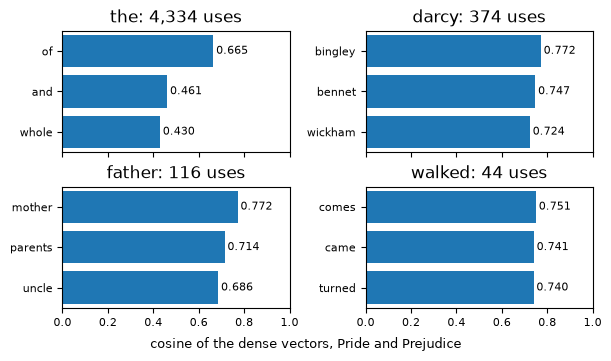

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(6, 3.5), sharex=True, layout="constrained")
for ax, w in zip(axes.flat, ("the", "darcy", "father", "walked")):
    near = neighbours(w)
    bars = ax.barh(range(len(near)), [c for _, c in near], tick_label=[v for v, _ in near])
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)
    ax.set(title=f"{w}: {tokens.count(w):,} uses", xlim=(0, 1), ylim=(len(near) - 0.5, -0.5))
fig.supxlabel("cosine of the dense vectors, Pride and Prejudice", fontsize=9)
plt.show()

**Exercise.** FastText adds the markers < and > to a word and cuts it into
character n-grams of lengths 3 to 6. A word in its vocabulary gets the sum of
their vectors and its own; a word unseen in training has no vector of its own
and gets the sum of its n-gram vectors alone, from n-grams it shares with known
words. Set `FASTTEXT_WORD` to `chased`, then to a word of your own, and rerun
the cell. How many n-grams does FastText cut from each word, and how many
vectors does it sum when the word is in its vocabulary and when it is unseen?

In [9]:
FASTTEXT_WORD = "where"

grams = ngrams(FASTTEXT_WORD)
for k in range(LENGTHS[0], LENGTHS[1] + 1):
    print(f"length {k}: " + ("  ".join(g for g in grams if len(g) == k) or "none"))
print(f"n-grams: {len(grams)}; vectors: {len(grams) + 1} in the vocabulary, {len(grams)} unseen")

length 3: <wh  whe  her  ere  re>
length 4: <whe  wher  here  ere>
length 5: <wher  where  here>
length 6: <where  where>
n-grams: 14; vectors: 15 in the vocabulary, 14 unseen


### Solution

In [10]:
words = list(dict.fromkeys(["where", "chased", "kittens", word_of("FASTTEXT_WORD", FASTTEXT_WORD)]))
counts = "; ".join(f"`{w}` {len(ngrams(w))} n-grams, {len(ngrams(w)) + 1} vectors in a vocabulary and {len(ngrams(w))} unseen, a count of "
                   f"{tokens.count(w):,} in the novel, so {'among' if w in index else 'outside'} its words seen at least {MIN_COUNT} times" for w in words)
lists = [f"`{w}` " + ", ".join(f"`{v}` {c:.3f}" for v, c in neighbours(w)) for w in ("the", "darcy", "father", "walked")]
display(Markdown(f"FastText's markers give a word of L letters max(0, L + 3 − n) n-grams of each length n: {counts}. The frame on "
                 "FastText's n-grams of `where` counts the word's own vector. The nearest words by the novel's dense vectors: "
                 f"{'; '.join(lists)}. The puzzle's answer, as the note of the frame 'Company, Prediction and One Point per Word' "
                 f"gives it: by company `dog` is closer to `cat` than `mat` is, {cos(company()['cat'], company()['dog']):.3f} against "
                 f"{cos(company()['cat'], company()['mat']):.3f}, and skip-gram at its optimum fits each dot product to the PMI of those counts minus ln K."))

FastText's markers give a word of L letters max(0, L + 3 − n) n-grams of each length n: `where` 14 n-grams, 15 vectors in a vocabulary and 14 unseen, a count of 90 in the novel, so among its words seen at least 5 times; `chased` 18 n-grams, 19 vectors in a vocabulary and 18 unseen, a count of 0 in the novel, so outside its words seen at least 5 times; `kittens` 22 n-grams, 23 vectors in a vocabulary and 22 unseen, a count of 0 in the novel, so outside its words seen at least 5 times. The frame on FastText's n-grams of `where` counts the word's own vector. The nearest words by the novel's dense vectors: `the` `of` 0.665, `and` 0.461, `whole` 0.430; `darcy` `bingley` 0.772, `bennet` 0.747, `wickham` 0.724; `father` `mother` 0.772, `parents` 0.714, `uncle` 0.686; `walked` `comes` 0.751, `came` 0.741, `turned` 0.740. The puzzle's answer, as the note of the frame 'Company, Prediction and One Point per Word' gives it: by company `dog` is closer to `cat` than `mat` is, 0.913 against 0.816, and skip-gram at its optimum fits each dot product to the PMI of those counts minus ln K.